<a href="https://colab.research.google.com/github/raghavendrapon/CodeAlpha_ProjectName/blob/main/brain_tumor_yolov11(You_Only_Look_Once_version_11).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
pkdarabi_medical_image_dataset_brain_tumor_detection_path = kagglehub.dataset_download('pkdarabi/medical-image-dataset-brain-tumor-detection')

print('Data source import complete.')

100%|██████████| 297M/297M [00:02<00:00, 138MB/s]

Extracting files...


Data source import complete.


In [ ]:
from tqdm.auto import tqdm

import os
import requests
import zipfile
import cv2
import math
import matplotlib.pyplot as plt
import glob
import numpy as np
import random
import seaborn as sns
import pandas as pd

from PIL import Image
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.4 MB/s eta 0:00:00


In [ ]:
import os

# Print dataset path
print(pkdarabi_medical_image_dataset_brain_tumor_detection_path)

# List files inside the dataset directory
for root, dirs, files in os.walk(pkdarabi_medical_image_dataset_brain_tumor_detection_path):
    print(root, dirs, files)
    break  # just show top-level

/root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5
/root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5 ['BrainTumor'] []


In [ ]:
import os
print(os.listdir(pkdarabi_medical_image_dataset_brain_tumor_detection_path))

['BrainTumor']


In [ ]:
import os
print(os.listdir(os.path.join(pkdarabi_medical_image_dataset_brain_tumor_detection_path, 'BrainTumor')))

['BrainTumorYolov8', 'BrainTumorYolov9', 'BrainTumorYolov11']


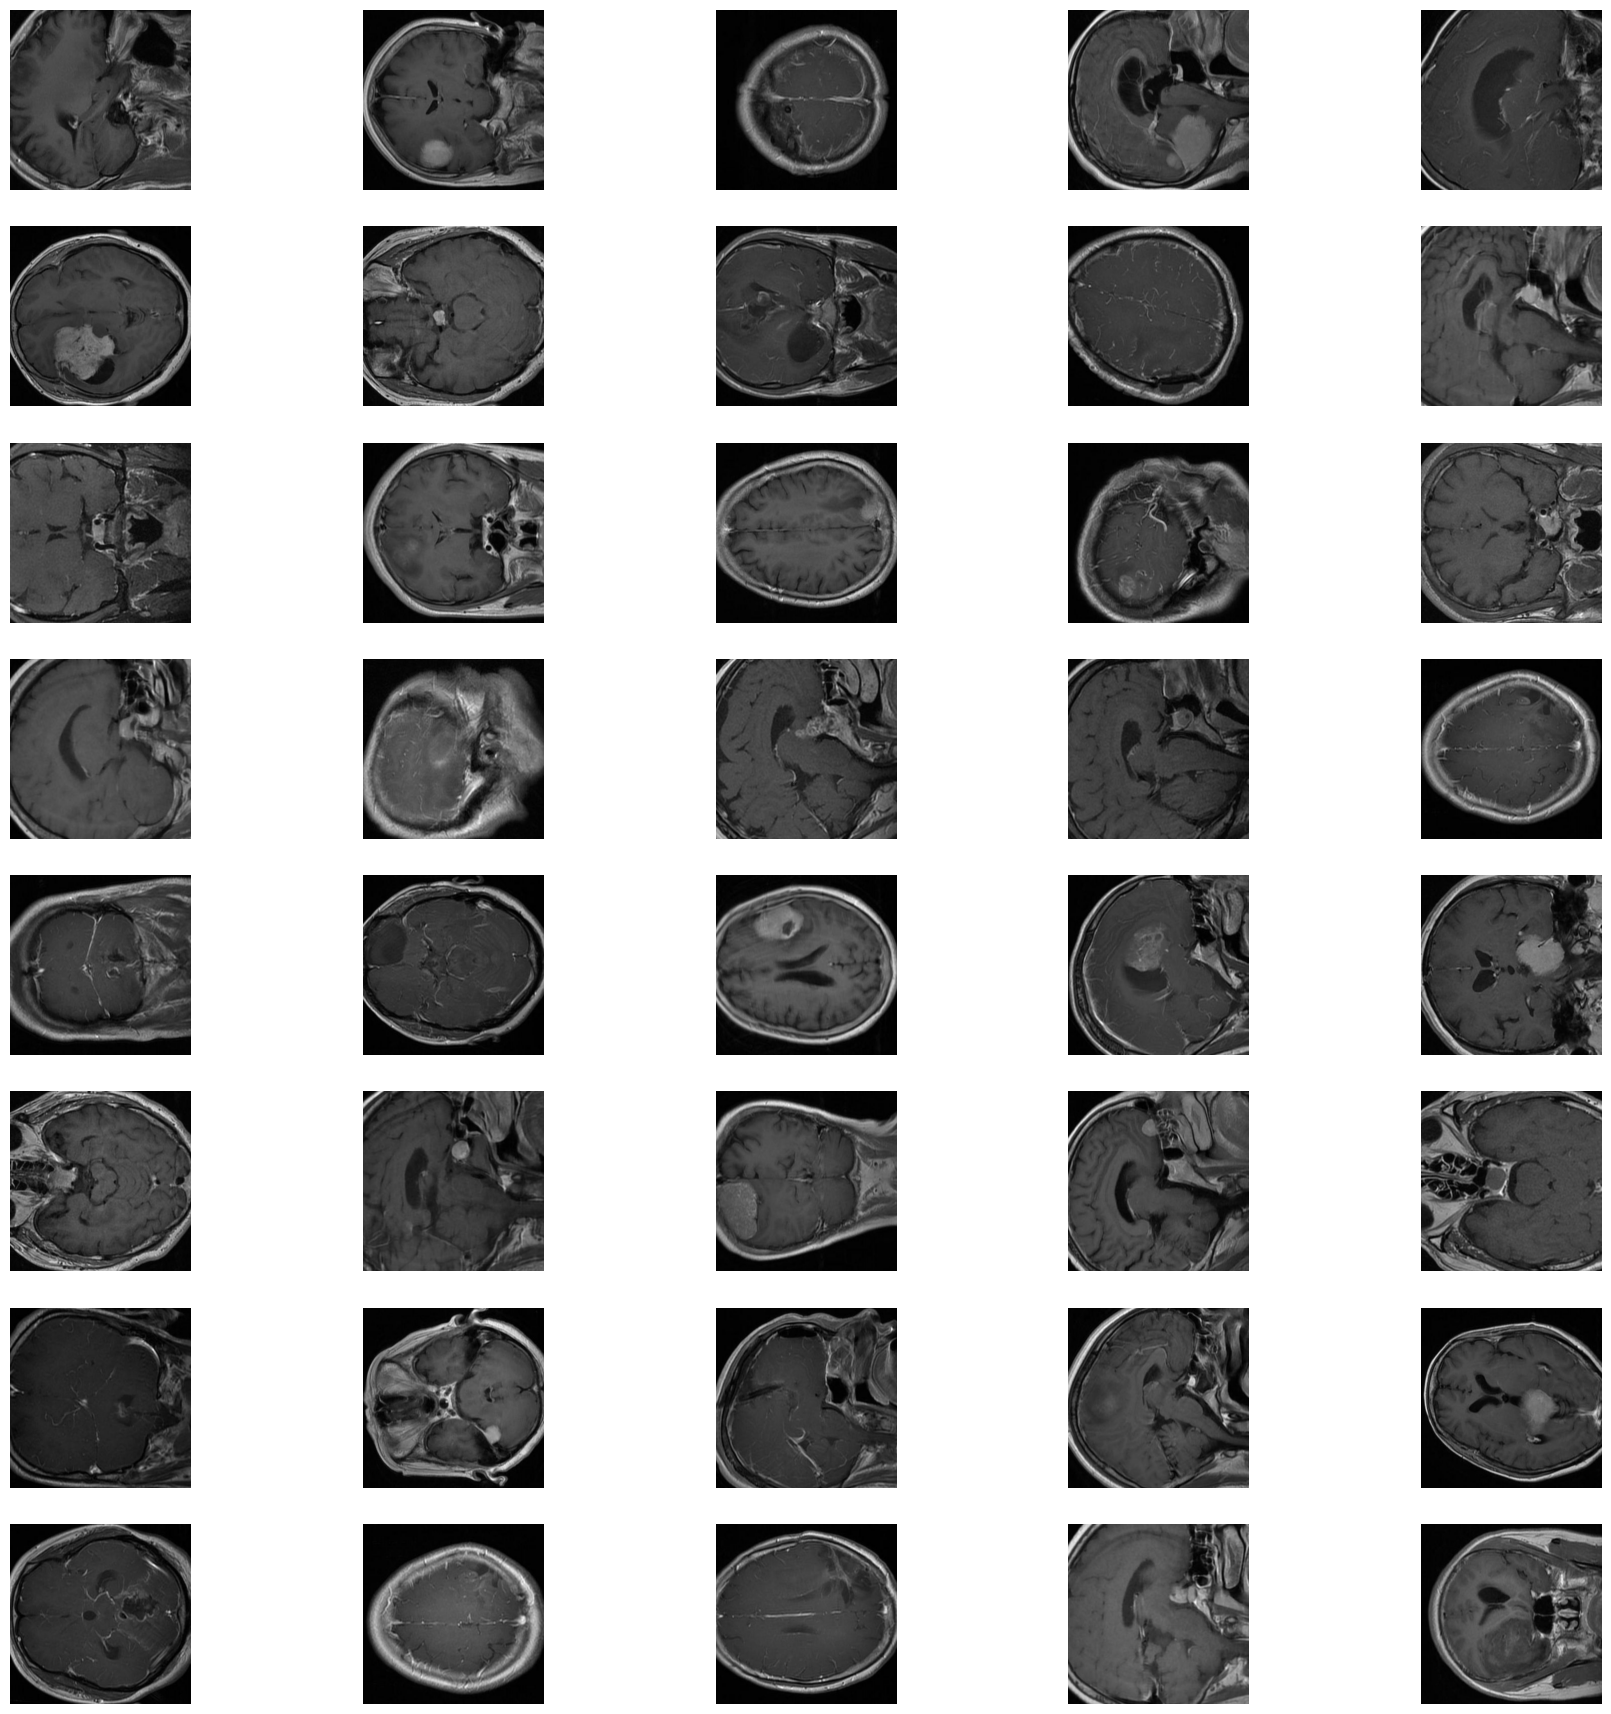

In [ ]:
import random
import cv2
import os
import matplotlib.pyplot as plt

image_dir = os.path.join(pkdarabi_medical_image_dataset_brain_tumor_detection_path, 'BrainTumor', 'BrainTumorYolov11', 'train', 'images')
label_files = os.path.join(pkdarabi_medical_image_dataset_brain_tumor_detection_path, 'BrainTumor', 'BrainTumorYolov11', 'train', 'labels')

image_files = os.listdir(image_dir)
random_images = random.sample(image_files, 40)

fig, axs = plt.subplots(8, 5, figsize=(22, 22))
axs = axs.flatten()

for i, image_file in enumerate(random_images):
    image_path = os.path.join(image_dir, image_file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    label_file = os.path.splitext(image_file)[0] + ".txt"
    label_path = os.path.join(label_files, label_file)

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            labels = f.read().strip().split("\n")

        for label in labels:
            if len(label.split()) != 5:
                continue
            class_id, x_center, y_center, width, height = map(float, label.split())
            x_min = int((x_center - width / 2) * image.shape[1])
            y_min = int((y_center - height / 2) * image.shape[0])
            x_max = int((x_center + width / 2) * image.shape[1])
            y_max = int((y_center + height / 2) * image.shape[0])

            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)

            text_scale = max(0.5, min(image.shape[1], image.shape[0]) / 700)
            text_thickness = max(1, int(text_scale * 2))
            classe = class_names[int(class_id)]
            cv2.putText(
                image,
                classe,
                (x_min, max(y_min - 10, 0)),
                cv2.FONT_HERSHEY_SIMPLEX,
                text_scale,
                (0, 0, 255),
                text_thickness,
                cv2.LINE_AA,
            )

    axs[i].imshow(image)
    axs[i].axis('off')

plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

In [ ]:
from ultralytics import YOLO
model=YOLO('yolo11s.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
 model.train(
   data=os.path.join(pkdarabi_medical_image_dataset_brain_tumor_detection_path, 'BrainTumor', 'BrainTumorYolov8', 'data.yaml'),
   imgsz=256,
   epochs=30,
   batch=16)

Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False

Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

 11                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 12             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 13                  -1  1    443776  ultralytics.nn.modules.block.C3k2            [768, 256, 1, False]          
 14                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 15             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 16                  -1  1    127680  ultralytics.nn.modules.block.C3k2            [512, 128, 1, False]          
 17                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 18            [-1, 13]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 19                  -1  1    345472  ultralytics.nn.modules.block.C3k2            [384,

train: Scanning /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/train/labels... 2144 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2144/2144 [00:04<00:00, 523.92it/s]

train: New cache created: /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/train/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2143, len(boxes) = 2144. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...

                   all        612        612      0.894      0.874      0.918      0.699



30 epochs completed in 6.419 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 19.1MB
Optimizer stripped from runs/detect/train/weights/best.pt, 19.1MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 100 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 20/20 [01:14<00:00,  3.74s/it]


                   all        612        612      0.894      0.874      0.918      0.699
                glioma        285        285       0.85      0.736      0.815      0.532
            meningioma        142        142      0.919      0.962      0.972      0.818
             pituitary        185        185      0.913      0.924      0.966      0.747
Speed: 0.5ms preprocess, 115.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7840738515b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
metrics = model.val(split='val')

print(f"Mean Average Precision @.5:.95 : {metrics.box.map}")
print(f"Mean Average Precision @ .50   : {metrics.box.map50}")
print(f"Mean Average Precision @ .70   : {metrics.box.map75}")
print("recall : ",metrics.box.r)
print(metrics.box.f1)
print(metrics.box.maps)

Ultralytics 8.3.184 🚀 Python-3.12.11 torch-2.8.0+cu126 CPU (Intel Xeon 2.20GHz)
YOLO11s summary (fused): 100 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 834.0±337.0 MB/s, size: 34.4 KB)


val: Scanning /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/valid/labels.cache... 612 images, 0 backgrounds, 0 corrupt: 100%|██████████| 612/612 [00:00<?, ?it/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 39/39 [01:10<00:00,  1.81s/it]


                   all        612        612      0.894      0.874      0.918      0.699
                glioma        285        285       0.85      0.736      0.815      0.532
            meningioma        142        142      0.919      0.962      0.972      0.818
             pituitary        185        185      0.913      0.924      0.966      0.747
Speed: 0.4ms preprocess, 108.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to runs/detect/train2
Mean Average Precision @.5:.95 : 0.6990340396230266
Mean Average Precision @ .50   : 0.9177497738327466
Mean Average Precision @ .70   : 0.7927014866984949
recall :  [    0.73572     0.96161     0.92432]
[    0.78875     0.93994     0.91864]
[    0.53229     0.81822     0.74659]


In [ ]:
from IPython.display import Image,display
path='/content/runs/detect/train'
image=[f for f in os.listdir(path) if f.endswith(('.jpg','.png','.jpeg'))]
for i in image:
    display(Image(os.path.join(path,i)))


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1432_jpg.rf.4421cea6f83014485c4b6bf5aafdbd86.jpg: 256x256 1 pituitary, 188.0ms
Speed: 2.2ms preprocess, 188.0ms inference, 21.6ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train3


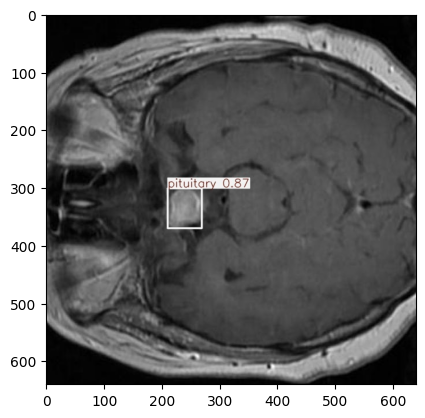


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1037_jpg.rf.7c415f051556bbba83bc00f70fe54818.jpg: 256x256 1 pituitary, 166.4ms
Speed: 3.4ms preprocess, 166.4ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train4


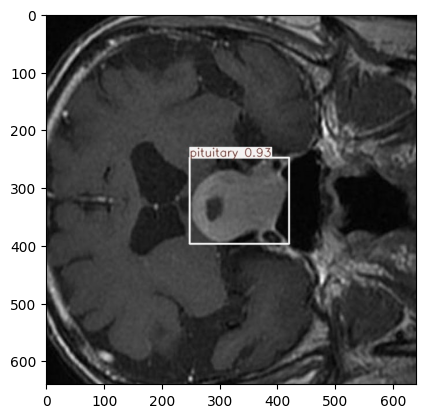


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/663_jpg.rf.317c1dda38684f7a28865be102d29686.jpg: 256x256 1 meningioma, 152.5ms
Speed: 1.8ms preprocess, 152.5ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train5


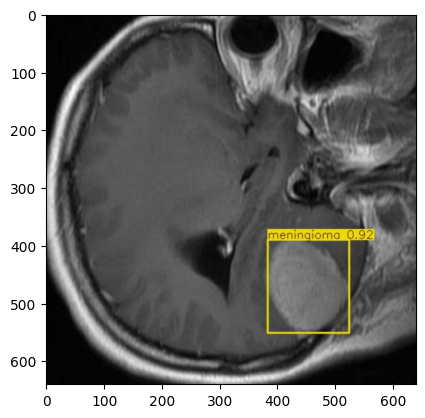


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2986_jpg.rf.dbda892491521eb209234b34bccdcdb0.jpg: 256x256 1 glioma, 158.8ms
Speed: 1.6ms preprocess, 158.8ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train6


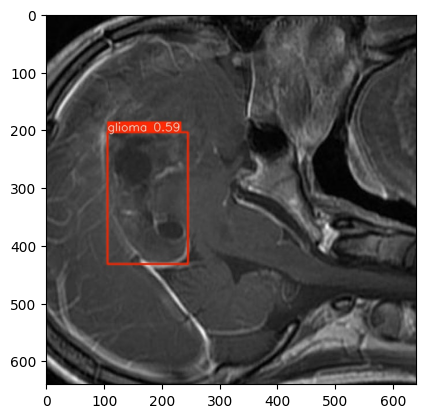


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2548_jpg.rf.ac53adca8ccdd9528c674565e3fc089f.jpg: 256x256 1 glioma, 164.5ms
Speed: 1.8ms preprocess, 164.5ms inference, 2.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train7


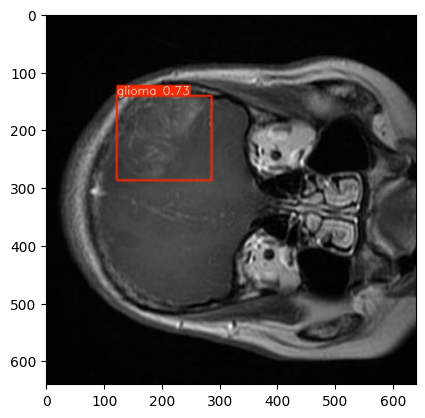


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1178_jpg.rf.05e49b5e0a7310cbbdecc37e48153491.jpg: 256x256 1 pituitary, 131.2ms
Speed: 1.8ms preprocess, 131.2ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train8


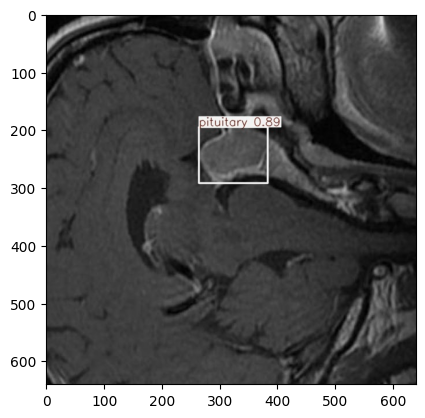


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/979_jpg.rf.8fad468a4755ad718f4a8b8b6893535c.jpg: 256x256 1 pituitary, 121.0ms
Speed: 1.9ms preprocess, 121.0ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train9


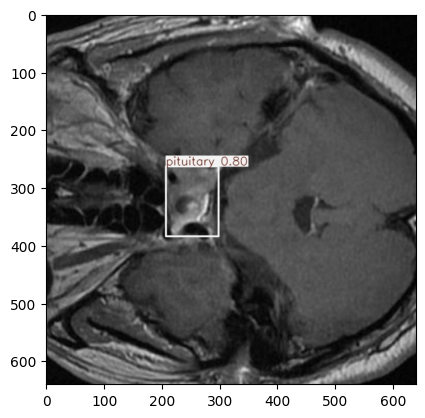


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2968_jpg.rf.a0cb25df31fb4976b1f3e4cefd4c99f0.jpg: 256x256 1 glioma, 124.5ms
Speed: 1.8ms preprocess, 124.5ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train10


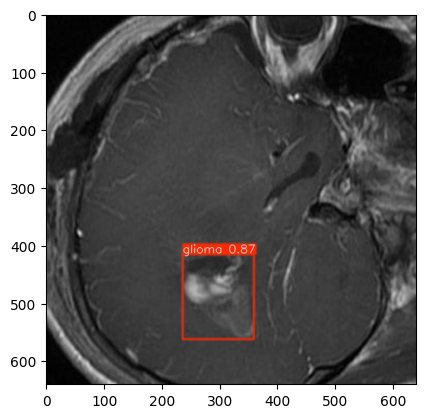


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/940_jpg.rf.b20d2f1451241d70bbbc6f6599180f2e.jpg: 256x256 1 pituitary, 143.5ms
Speed: 1.7ms preprocess, 143.5ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train11


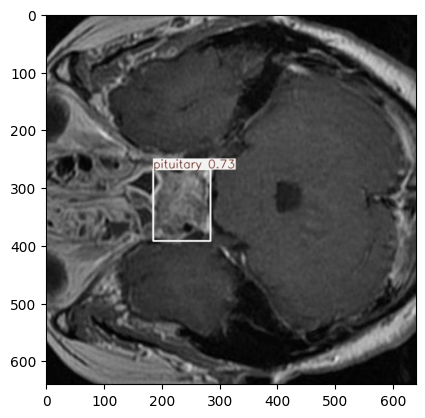


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/233_jpg.rf.f8e76a85f9415a5bb5b8bd9f6cd8c5be.jpg: 256x256 1 meningioma, 129.7ms
Speed: 2.9ms preprocess, 129.7ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train12


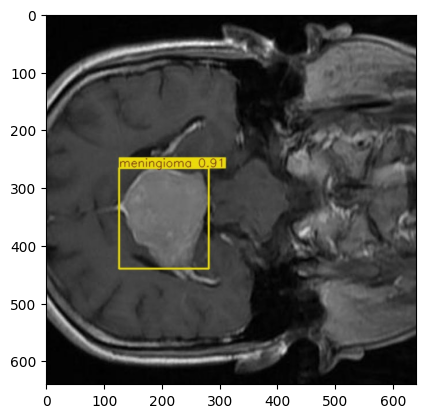


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2657_jpg.rf.3682b4bc734fbc4ace8d831043c87fe9.jpg: 256x256 2 gliomas, 141.7ms
Speed: 1.9ms preprocess, 141.7ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train13


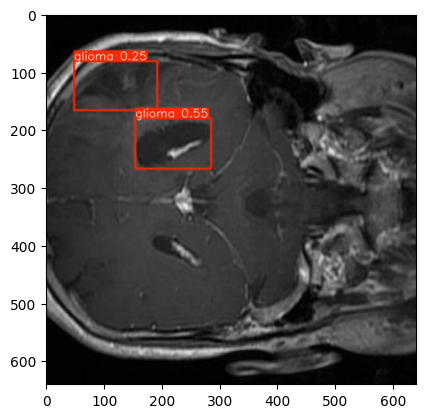


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/341_jpg.rf.8b912d015591484f95a1f7d21a7305ca.jpg: 256x256 1 meningioma, 151.0ms
Speed: 1.8ms preprocess, 151.0ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train14


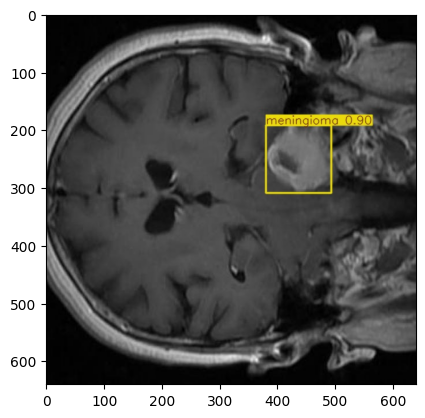


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/3003_jpg.rf.4a331d96dc252f259f08c9046c4ae490.jpg: 256x256 1 glioma, 138.3ms
Speed: 1.8ms preprocess, 138.3ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train15


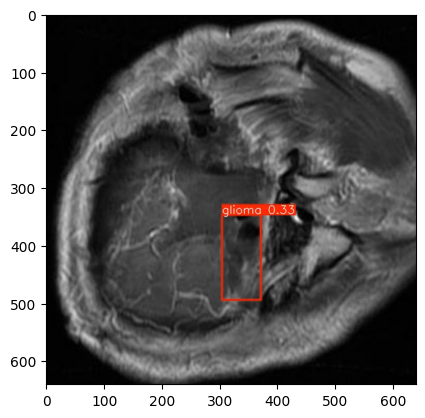


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/309_jpg.rf.33785c14232d6ede3876d09968debfac.jpg: 256x256 1 meningioma, 136.6ms
Speed: 1.8ms preprocess, 136.6ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train16


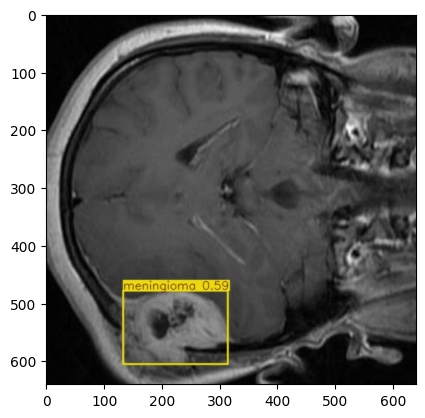


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2531_jpg.rf.608517f4444d6322e094245b4099acd9.jpg: 256x256 2 gliomas, 147.8ms
Speed: 1.9ms preprocess, 147.8ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train17


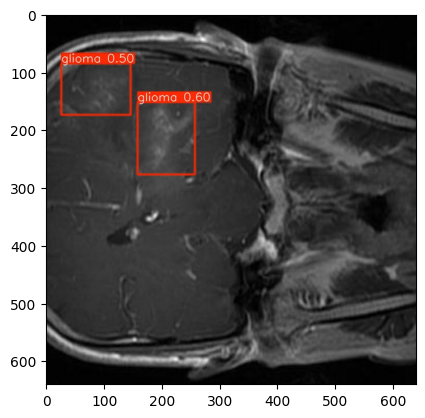


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/281_jpg.rf.a21bc0f6896e0d182d7a858f4ab7e4ae.jpg: 256x256 1 meningioma, 142.3ms
Speed: 1.8ms preprocess, 142.3ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train18


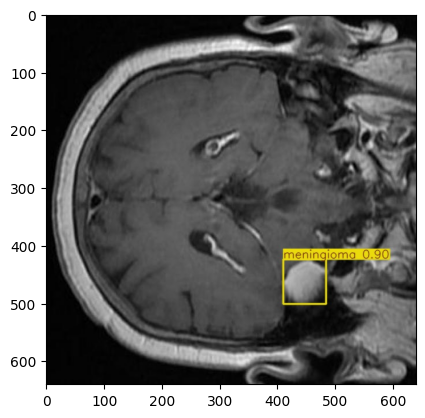


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1231_jpg.rf.ff2478caf59fb9b4e63ae6190608b1eb.jpg: 256x256 1 pituitary, 145.5ms
Speed: 1.7ms preprocess, 145.5ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train19


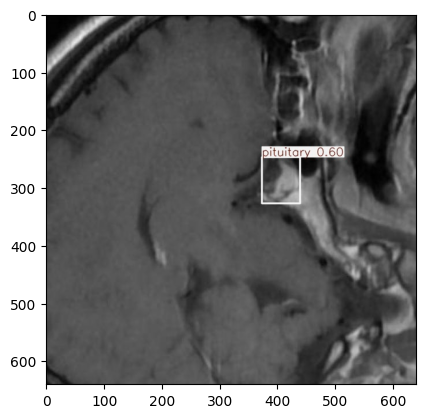


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/3001_jpg.rf.1c8c3754bf91838f91711e73bb28ec50.jpg: 256x256 2 gliomas, 141.3ms
Speed: 1.7ms preprocess, 141.3ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train20


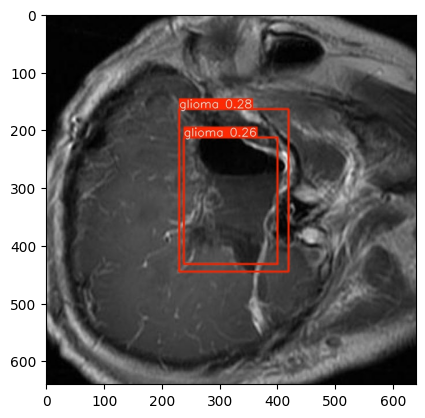


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2644_jpg.rf.a0fc4011f23db39f54925c2a1a997bfb.jpg: 256x256 1 glioma, 151.0ms
Speed: 1.7ms preprocess, 151.0ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train21


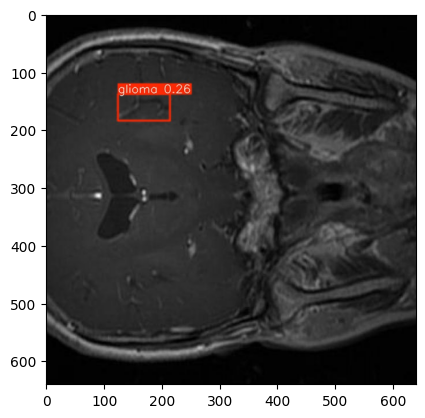


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2153_jpg.rf.b7046b5b3aa144bdd718c4a60e16ba6c.jpg: 256x256 2 gliomas, 187.7ms
Speed: 1.9ms preprocess, 187.7ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train22


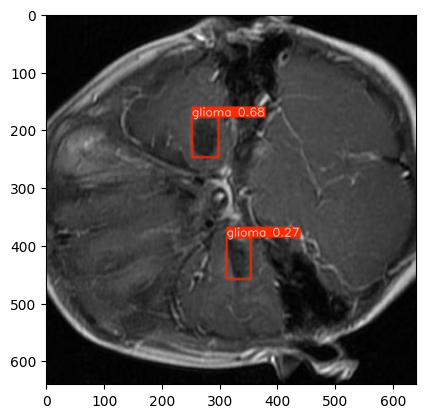


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2717_jpg.rf.be5ba1a6b59da5b6335d7ca8cb12529e.jpg: 256x256 1 glioma, 150.3ms
Speed: 1.8ms preprocess, 150.3ms inference, 1.1ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train23


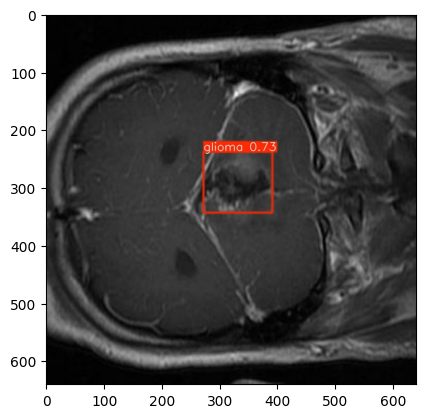


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/937_jpg.rf.f1aeff71adf047fc3774da3706a9c18d.jpg: 256x256 1 pituitary, 167.7ms
Speed: 1.8ms preprocess, 167.7ms inference, 1.8ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train24


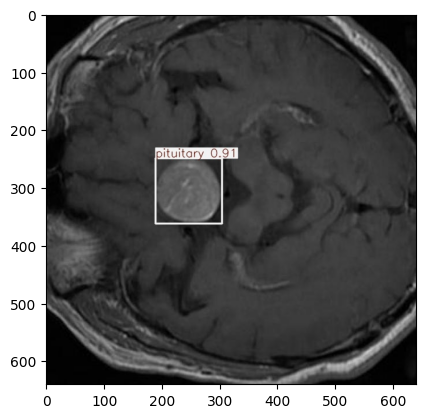


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/38_jpg.rf.1a9b0715faf5528bc2070c2b8e786241.jpg: 256x256 1 meningioma, 1 pituitary, 162.1ms
Speed: 1.8ms preprocess, 162.1ms inference, 1.4ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train25


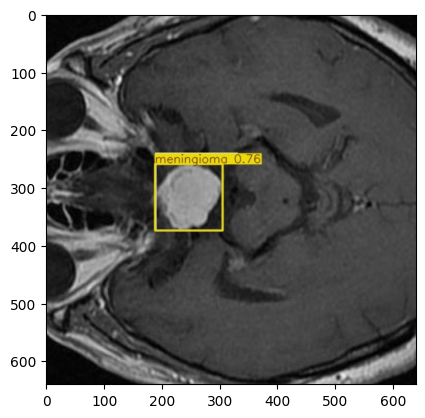


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1396_jpg.rf.d60b91690a7b887309eda8226986764f.jpg: 256x256 1 pituitary, 152.7ms
Speed: 1.8ms preprocess, 152.7ms inference, 1.4ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train26


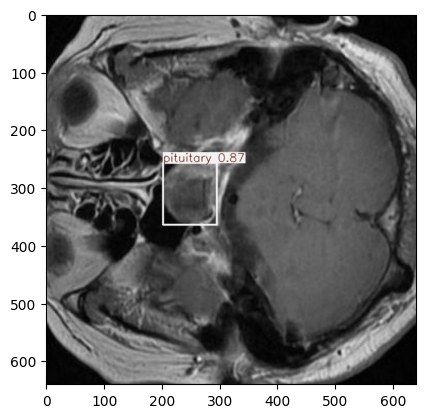


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1342_jpg.rf.d282167faddbd34230fe5dd2e536e7c5.jpg: 256x256 1 pituitary, 195.8ms
Speed: 1.8ms preprocess, 195.8ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train27


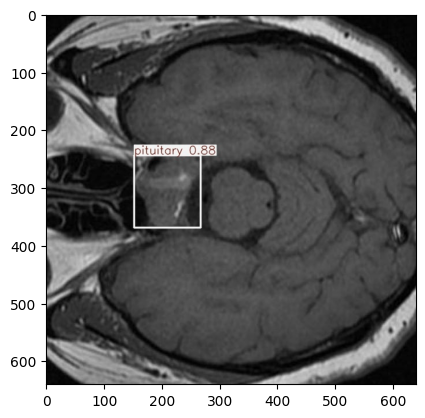


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2320_jpg.rf.96ade57fc72ea3c9b1c5d969ed11658a.jpg: 256x256 2 gliomas, 168.3ms
Speed: 1.9ms preprocess, 168.3ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train28


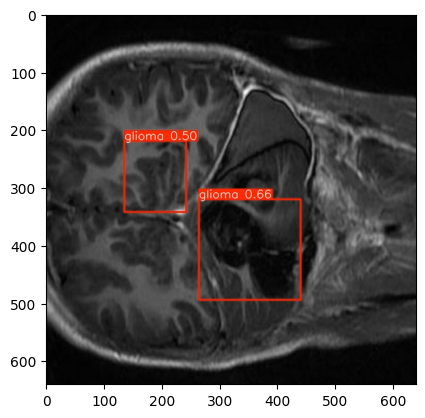


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2617_jpg.rf.62e2abf10342499048df0f87c99e3682.jpg: 256x256 1 glioma, 153.8ms
Speed: 1.8ms preprocess, 153.8ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train29


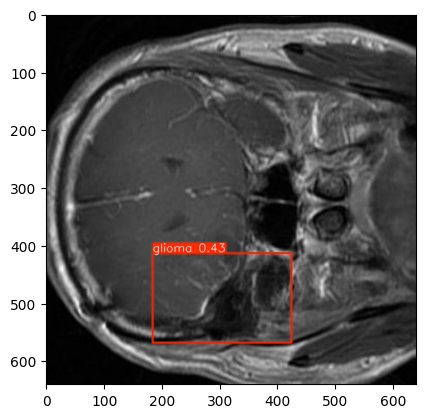


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2033_jpg.rf.a8066ff978dec1e789ccfd53e2f32b95.jpg: 256x256 1 glioma, 158.9ms
Speed: 1.8ms preprocess, 158.9ms inference, 1.4ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train30


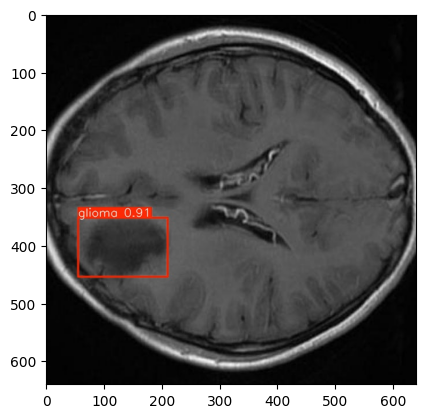


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/571_jpg.rf.ed65129e8c11ba5cc4761d5fbee49eff.jpg: 256x256 1 meningioma, 160.8ms
Speed: 1.7ms preprocess, 160.8ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train31


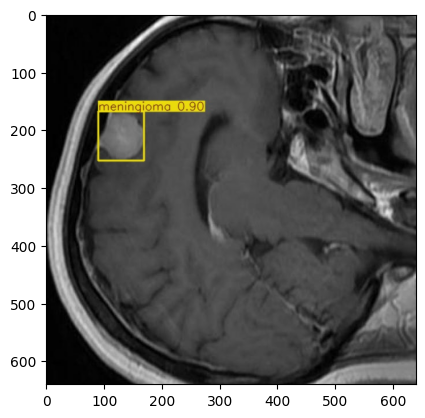


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1616_jpg.rf.183ca40290650cf04b3d0f19a5731488.jpg: 256x256 1 pituitary, 170.6ms
Speed: 1.8ms preprocess, 170.6ms inference, 1.9ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train32


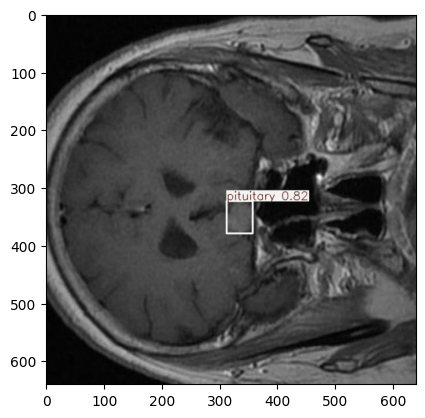


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/10_jpg.rf.efaf1af26de11dabdda3214f4457c931.jpg: 256x256 1 meningioma, 173.9ms
Speed: 1.7ms preprocess, 173.9ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train33


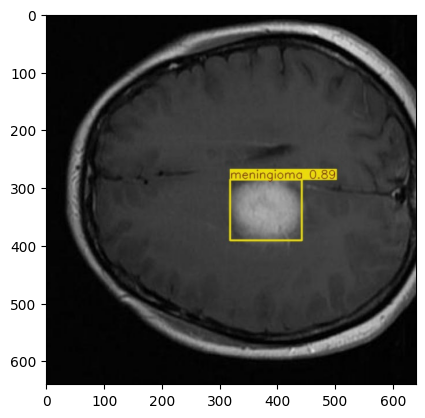


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/646_jpg.rf.518b0b892840ea6e76c2574add0b94b6.jpg: 256x256 1 meningioma, 158.5ms
Speed: 1.9ms preprocess, 158.5ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train34


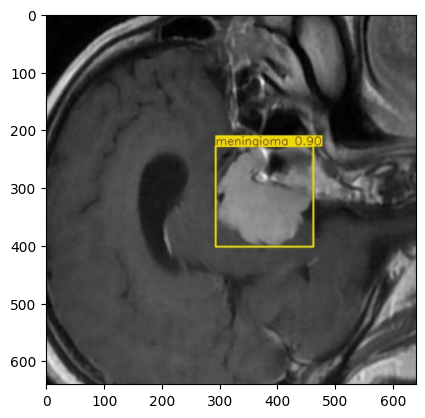


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/104_jpg.rf.e74d25768eb80e77624670d6bc966b81.jpg: 256x256 1 meningioma, 172.2ms
Speed: 1.9ms preprocess, 172.2ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train35


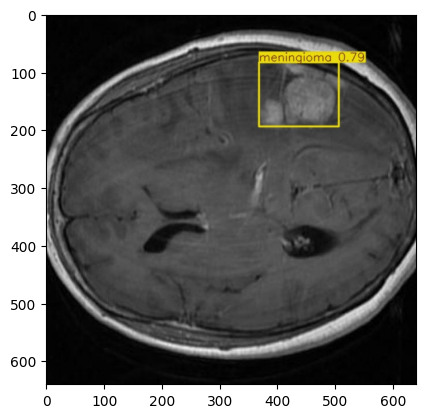


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2054_jpg.rf.f8fc31417ac7299e05ecd3da246915b8.jpg: 256x256 1 glioma, 183.9ms
Speed: 1.9ms preprocess, 183.9ms inference, 2.4ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train36


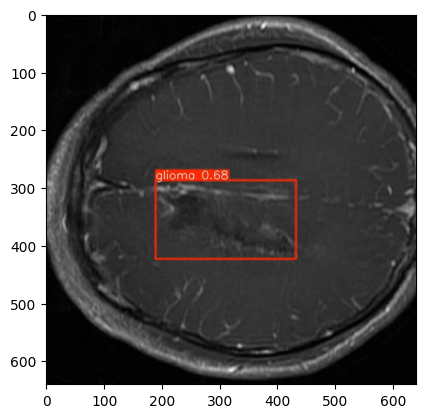


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1672_jpg.rf.69e40db584ad1c79aa6a5c46e6f3a5d9.jpg: 256x256 1 pituitary, 154.6ms
Speed: 1.9ms preprocess, 154.6ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train37


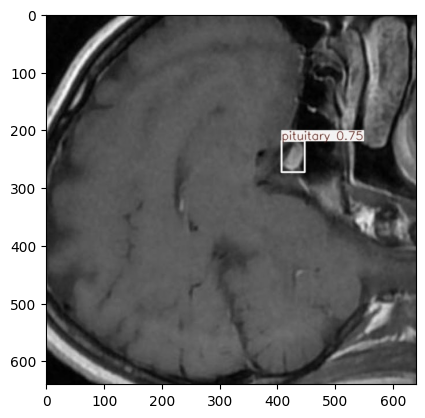


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/130_jpg.rf.f26fbad203da20d0a9c229b7ecbea70d.jpg: 256x256 2 meningiomas, 159.3ms
Speed: 1.8ms preprocess, 159.3ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train38


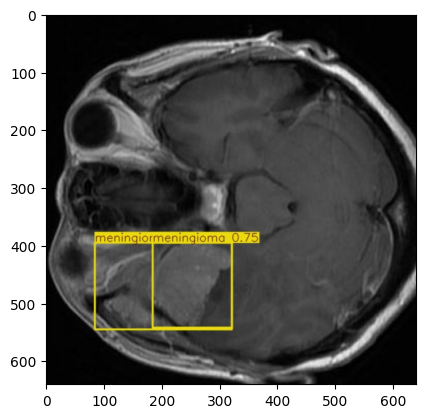


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1564_jpg.rf.c1e0dd340ba5960fc13e374a8ef4b7d5.jpg: 256x256 1 pituitary, 160.8ms
Speed: 1.8ms preprocess, 160.8ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train39


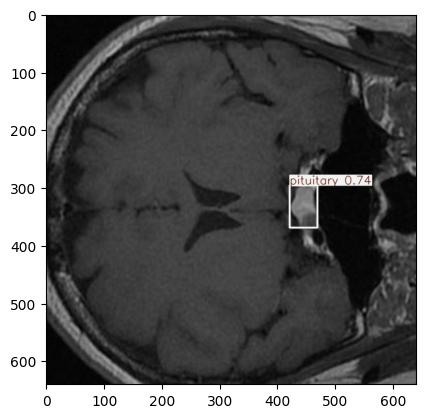


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1502_jpg.rf.545511fbefa8e14cdb8602a8bb4e59df.jpg: 256x256 1 pituitary, 155.4ms
Speed: 1.7ms preprocess, 155.4ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train40


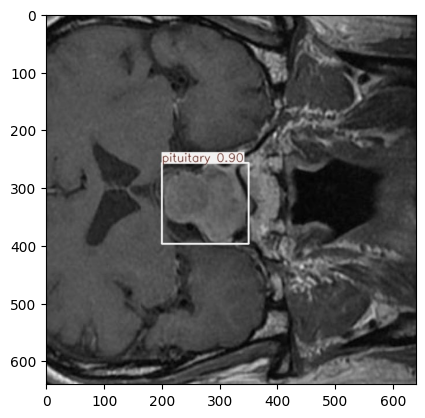


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1970_jpg.rf.8091ad01b620280c7171d511ce690e6e.jpg: 256x256 1 glioma, 167.2ms
Speed: 1.7ms preprocess, 167.2ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train41


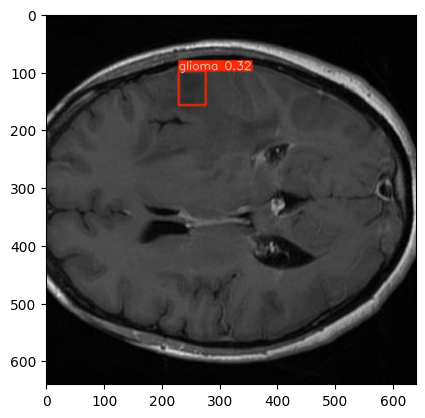


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/3042_jpg.rf.8e9abeea8293c539d7b839b728e90785.jpg: 256x256 2 gliomas, 156.8ms
Speed: 1.8ms preprocess, 156.8ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train42


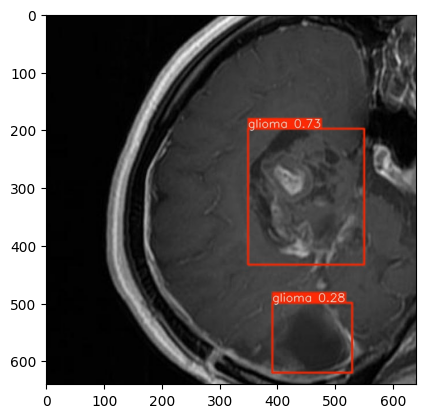


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/602_jpg.rf.bbb51d078837e053c54dac0180c2913f.jpg: 256x256 1 meningioma, 152.4ms
Speed: 1.7ms preprocess, 152.4ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train43


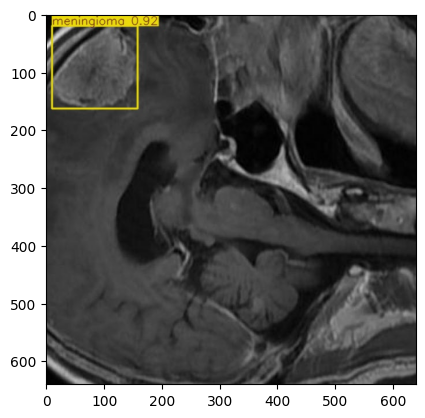


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2488_jpg.rf.548bbaa4ca83edc355bedb85aafef322.jpg: 256x256 3 gliomas, 157.2ms
Speed: 1.8ms preprocess, 157.2ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train44


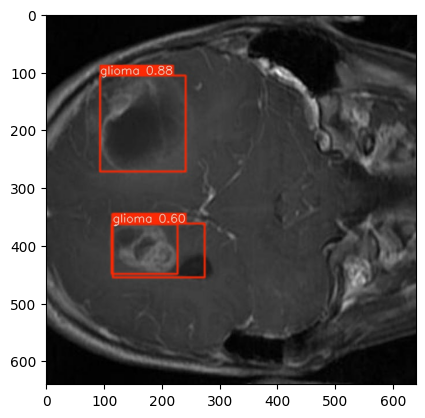


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/1511_jpg.rf.f149f5d409cca5df3f6c90f716e81244.jpg: 256x256 2 pituitarys, 152.9ms
Speed: 1.7ms preprocess, 152.9ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train45


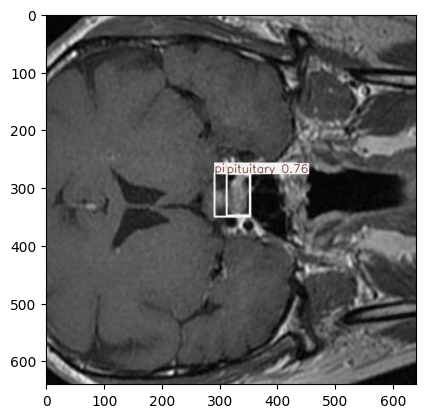


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/2297_jpg.rf.ee0c9d2ee893bc79156cf301e66abae7.jpg: 256x256 1 glioma, 158.0ms
Speed: 1.9ms preprocess, 158.0ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train46


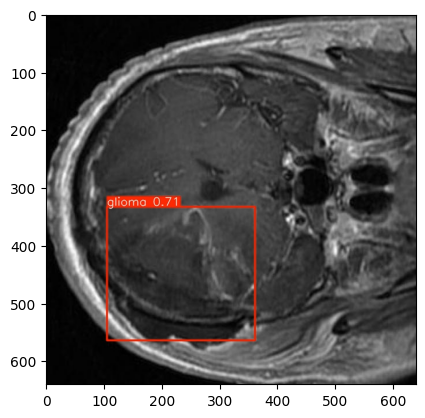


image 1/1 /root/.cache/kagglehub/datasets/pkdarabi/medical-image-dataset-brain-tumor-detection/versions/5/BrainTumor/BrainTumorYolov8/test/images/171_jpg.rf.93acd56beb32156ecb4cf8b77fcc98fb.jpg: 256x256 1 meningioma, 154.4ms
Speed: 1.7ms preprocess, 154.4ms inference, 1.7ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/detect/train47


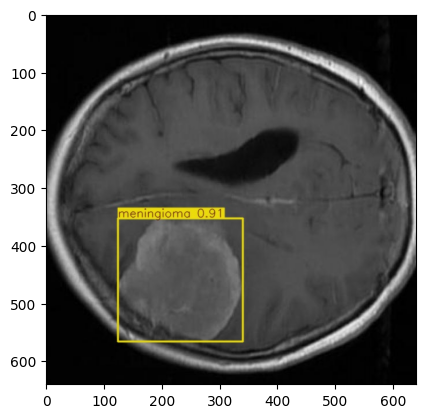

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2

image_dir = os.path.join(pkdarabi_medical_image_dataset_brain_tumor_detection_path, 'BrainTumor', 'BrainTumorYolov8', 'test', 'images')

all_images = os.listdir(image_dir)[:45]
for i in all_images:
    results = model.predict(os.path.join(image_dir, i), save=True)
    image_path = os.path.join(results[0].save_dir, i)
    plt.imshow(cv2.imread(image_path))
    plt.show()